# Exploratory Data Analysis

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
game_level_features = pd.read_parquet("data/aggregated/game_level_features_22_25.parquet")
game_level_features["game_date"] = pd.to_datetime(game_level_features["game_date"], errors="coerce")
game_level_features.head(10)

,game_id,game_date,home_team,away_team,starter_pitcher_name_home,starter_pitcher_name_away,Δstarter_FIP_3G,Δstarter_WHIP_3G,Δstarter_K9_3G,Δstarter_HR9_3G,...,Δbullpen_K9_7G,Δbullpen_HR9_7G,Δroll_3G_OBP,Δroll_3G_ISO,Δroll_7G_OBP,Δroll_7G_ISO,ΔBIP_out_rate_3G,ΔBIP_out_rate_7G,home_win,run_diff
0,661042,2022-04-07,LAA,HOU,"Ohtani, Shohei","Valdez, Framber",-0.501346,-0.173269,2.362500,0.228462,...,-0.635330,-0.103930,-0.027160,-0.013193,-0.027160,-0.013193,-0.030054,-0.030054,0,-2
1,661577,2022-04-07,ATL,CIN,"Fried, Max","Mahle, Tyler",-0.500258,-0.156226,-1.896095,-0.385842,...,-1.483728,-0.356760,-0.011229,0.006274,-0.011229,0.006274,0.016629,0.016629,0,-3
2,662021,2022-04-07,STL,PIT,"Wainwright, Adam","Brubaker, JT",-1.496179,-0.272351,-1.838997,-1.136493,...,-0.060306,-0.387290,0.004731,0.038504,0.004731,0.038504,0.028652,0.028652,1,9
3,662571,2022-04-07,WSH,NYM,"Corbin, Patrick","Megill, Tylor",0.740873,0.193245,-2.388419,0.048493,...,-1.024415,0.294646,0.021413,0.008000,0.021413,0.008000,-0.004304,-0.004304,0,-4
4,662766,2022-04-07,KC,CLE,"Greinke, Zack","Bieber, Shane",1.678132,-0.063212,-6.238713,0.528978,...,-0.878869,-0.088981,0.005893,-0.019450,0.005893,-0.019450,-0.019316,-0.019316,1,2
5,663178,2022-04-07,CHC,MIL,"Hendricks, Kyle","Burnes, Corbin",3.291359,0.458473,-6.062442,1.182810,...,-0.751750,-0.130256,-0.005448,0.007685,-0.005448,0.007685,-0.019441,-0.019441,1,1
6,663418,2022-04-07,AZ,SD,"Bumgarner, Madison","Darvish, Yu",0.751171,0.133199,-3.039157,-0.018072,...,-1.574938,0.192973,-0.011187,-0.012834,-0.011187,-0.012834,-0.013363,-0.013363,1,2
7,661041,2022-04-08,LAA,HOU,"Detmers, Reid","Odorizzi, Jake",1.796577,0.580195,0.382809,0.753655,...,-1.780220,4.153846,-0.095925,-0.216749,-0.095925,-0.216749,-0.079051,-0.079051,0,-7
8,661131,2022-04-08,PHI,ATH,"Nola, Aaron","Montas, Frankie",-0.005405,-0.049099,1.079730,0.327027,...,1.578002,0.176460,-0.000515,-0.001215,-0.000515,-0.001215,-0.004885,-0.004885,1,4
9,661333,2022-04-08,NYY,BOS,"Cole, Gerrit","Eovaldi, Nathan",0.132353,-0.165441,2.382353,0.446691,...,-0.068105,0.037987,-0.005154,-0.016365,-0.005154,-0.016365,0.034455,0.034455,1,1


## Structural Examination

### Shape

In [3]:
game_level_features.shape

(9719, 30)

### Unique ID's

In [4]:
game_level_features["game_id"].is_unique

True

### Win Balance Outcome

In [5]:
game_level_features["home_win"].value_counts(normalize=True)

home_win
1    0.529581
0    0.470419
Name: proportion, dtype: float64

## Pitching Analysis 

### Starting Pitcher Distribution

In [6]:
game_level_features.filter(like="Δstarter").describe()

,Δstarter_FIP_3G,Δstarter_WHIP_3G,Δstarter_K9_3G,Δstarter_HR9_3G,Δstarter_FIP_7G,Δstarter_WHIP_7G,Δstarter_K9_7G,Δstarter_HR9_7G
count,9719.000000,9.719000e+03,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000
mean,0.017502,9.257598e-03,-0.013511,-0.003982,0.025266,0.008290,-0.017261,0.003231
std,2.792398,7.483961e-01,3.709555,1.585772,2.418433,0.663575,3.233184,1.354392
min,-62.750000,-2.294118e+01,-21.288462,-26.470588,-62.750000,-22.941176,-20.647059,-26.470588
25%,-1.472975,-3.573455e-01,-2.376179,-0.857143,-1.163762,-0.278768,-1.985711,-0.642367
50%,0.000000,2.220446e-16,0.000000,0.000000,0.015345,0.006435,0.000000,0.000000
75%,1.507484,3.750981e-01,2.376567,0.854376,1.218488,0.297676,1.981252,0.652020
max,35.666667,1.076786e+01,20.543478,21.000000,35.666667,10.956522,20.008929,21.000000


In [7]:
'''
Move to Script!
'''

def plot_delta_boxplots(
    df,
    like: str,
    title: str | None = None,
    feature_col: str = "Feature",
    value_col: str = "Value",
    figsize: tuple[int, int] = (12, 5),
    rotate_xticks: int = 90,
    dropna: bool = True,
) -> None:
    """
    Boxplot distributions for a set of columns selected via df.filter(like=...).

    Intended for quick EDA of delta features (e.g., Δstarter, Δbullpen).
    """
    sub = df.filter(like=like)
    if sub.shape[1] == 0:
        raise ValueError(f"No columns matched like='{like}'")

    long = sub.melt(var_name=feature_col, value_name=value_col)
    if dropna:
        long = long.dropna()

    plt.figure(figsize=figsize)
    sns.boxplot(data=long, x=feature_col, y=value_col)
    plt.xticks(rotation=rotate_xticks)
    plt.title(title or f"Boxplot Distribution for columns like '{like}'")
    plt.tight_layout()
    plt.show()

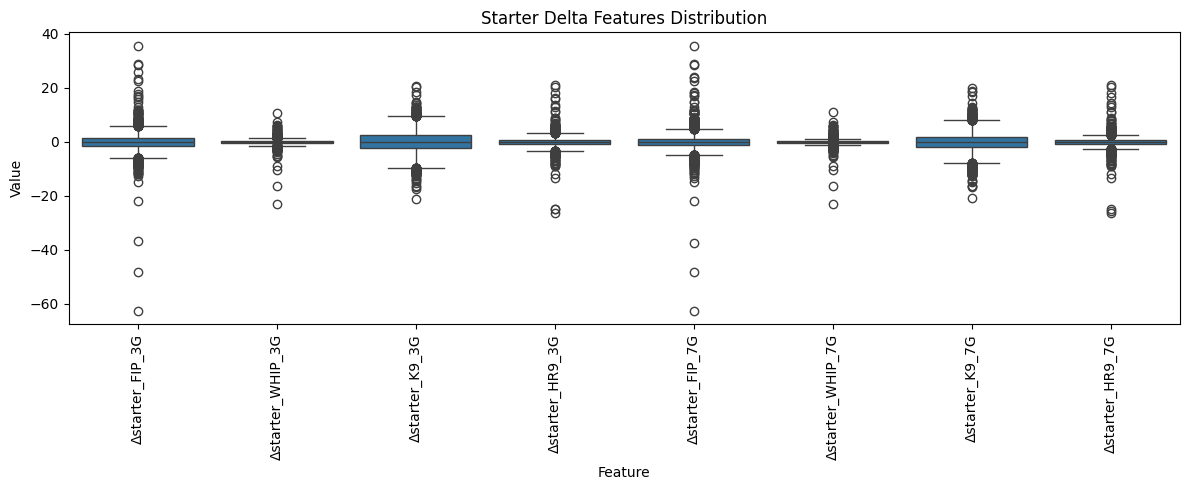

In [8]:
plot_delta_boxplots(game_level_features, like="Δstarter", title="Starter Delta Features Distribution")

#### Analysis

The distributions of the pitching delta features are generally centered around zero, with both the means and medians very close to zero. This is expected since the variables represent the difference between the home and away teams' metrics for a given game.

Overall, the distributions appear roughly symmetric around zero. Both the means and medians of the pitching delta features are very close to zero across all metrics, and the first and third quartiles are also fairly balanced around zero. This suggests that positive and negative pitching differences occur at similar rates across games.

As expected, the 3-game rolling windows (3G) show a wider spread compared to the 7-game rolling windows (7G). This makes sense because shorter rolling windows are more sensitive to recent performance and therefore tend to be noisier, while longer windows smooth out variability over a larger sample of games.

The number and magnitude of outliers appear relatively similar between the 3G and 7G windows, indicating that extreme differences between teams can occur regardless of the smoothing window.

Among the metrics, starter FIP exhibits the most extreme outliers, with some values reaching roughly −60 to +35. This likely reflects situations where there is a large difference in the recent performance of the two starting pitchers.

### Distribution by Win

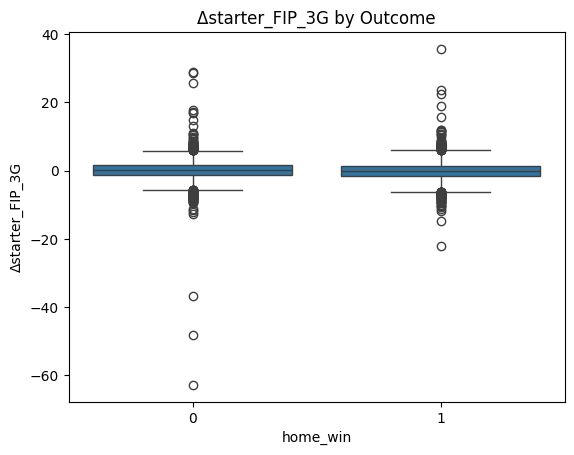

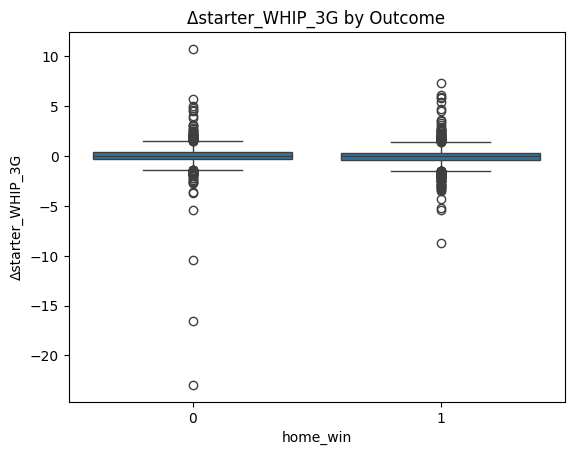

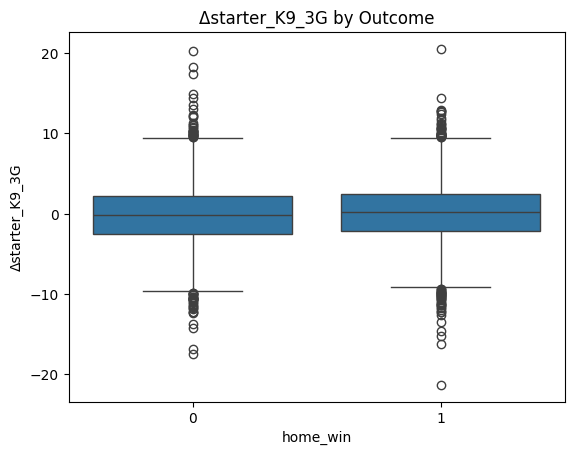

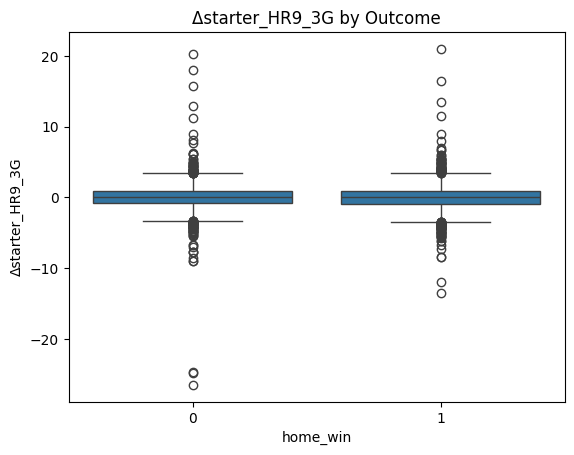

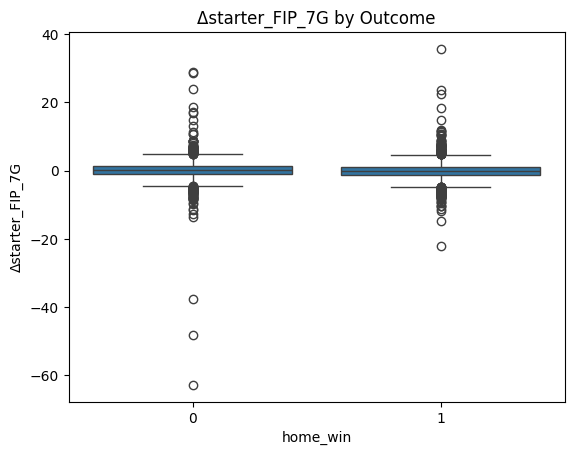

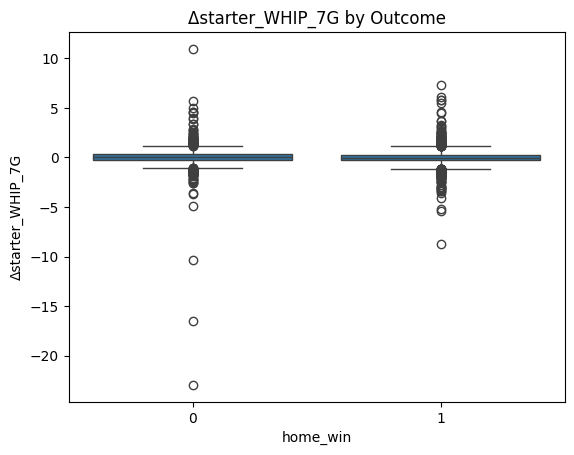

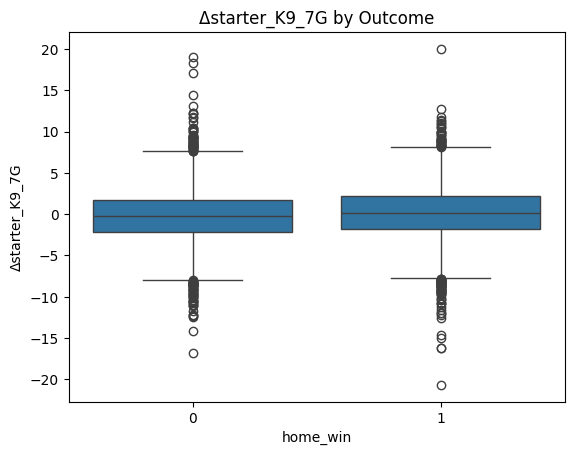

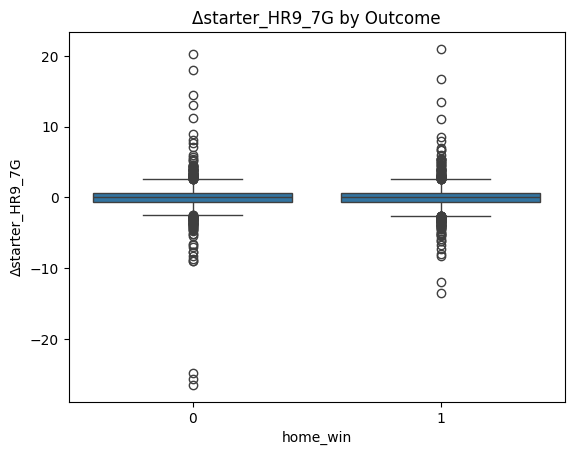

In [12]:
delta_starter = game_level_features.filter(like="Δstarter_")

for col in delta_starter.columns:
    plt.figure()
    sns.boxplot(
        data=game_level_features,
        x="home_win",
        y=col
    )
    plt.title(f"{col} by Outcome")
    plt.show()

#### Starter Pitching Delta Features by Game Outcome

Across all starter delta features (FIP, WHIP, K9, and HR9) for both the 3-game and 7-game rolling windows, the distributions are centered very close to zero for both home wins and losses. This indicates that in many games the recent performance of the home and away starting pitchers is relatively similar. The interquartile ranges and overall spreads of the distributions are also largely overlapping between outcomes, suggesting that no single starter metric alone strongly separates wins from losses. However, slight directional tendencies are visible: negative values of metrics where lower is better (such as $\Delta FIP$ and $\Delta WHIP$) and positive values where higher is better (such as $\Delta K9$) appear somewhat more common in the home win group. Overall, this suggests that starter matchup differences may contribute modest predictive signal, but are unlikely to fully explain game outcomes without considering other components such as bullpen performance and offensive strength.

### Bullpen Pitcher Distribution

In [10]:
game_level_features.filter(like="Δbullpen").describe()

,Δbullpen_FIP_3G,Δbullpen_WHIP_3G,Δbullpen_K9_3G,Δbullpen_HR9_3G,Δbullpen_FIP_7G,Δbullpen_WHIP_7G,Δbullpen_K9_7G,Δbullpen_HR9_7G
count,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000
mean,-0.099981,-0.027933,0.040103,-0.018575,0.019050,0.001935,0.035793,0.018601
std,2.559154,0.680857,3.615903,1.450991,1.738432,0.464508,2.526978,0.967504
min,-14.075051,-2.837143,-14.170807,-8.598377,-13.800000,-2.708333,-11.250000,-6.300000
25%,-1.700000,-0.465058,-2.319832,-0.900000,-1.063828,-0.302974,-1.637250,-0.584820
50%,-0.056250,-0.018634,0.072193,0.000000,0.017408,0.004412,0.046950,0.000000
75%,1.534149,0.421904,2.446719,0.843750,1.161917,0.306405,1.701640,0.622110
max,13.364764,3.583333,16.500000,7.838710,9.262987,3.583333,16.500000,6.750000


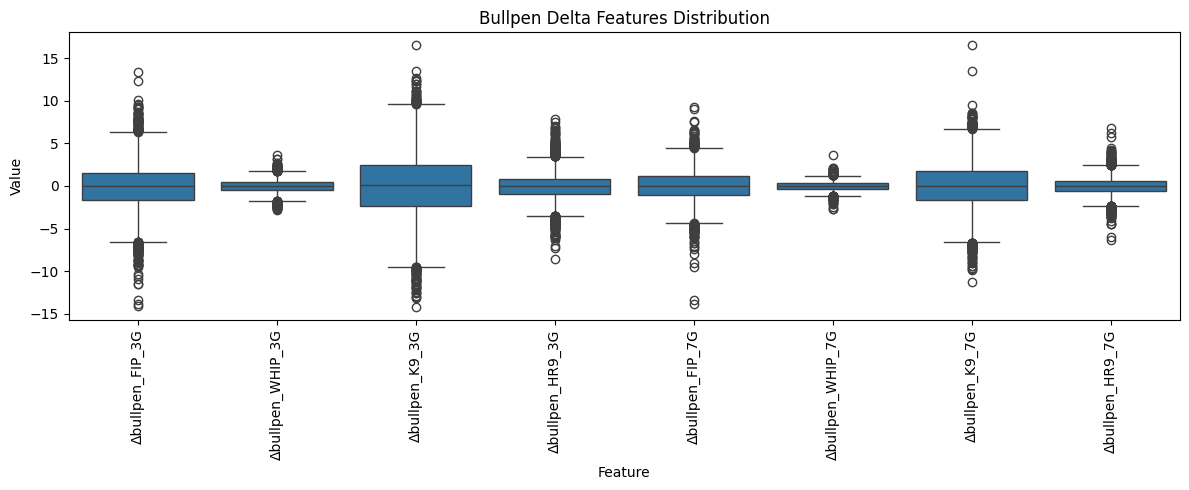

In [13]:
plot_delta_boxplots(game_level_features, like="bullpen", title="Bullpen Delta Features Distribution")

#### Analysis

The distributions of the bullpen delta features show patterns very similar to those observed for the starter delta features. Across all metrics, the distributions are centered close to zero, with both means and medians near zero, which is expected since these variables represent the difference between the home and away teams' bullpen performance.

As with the starter metrics, the 3-game rolling windows (3G) exhibit a wider spread than the 7-game windows (7G), reflecting the greater variability of shorter rolling samples. The overall shapes of the distributions are also fairly symmetric around zero.

One noticeable difference is that the bullpen features tend to exhibit slightly larger interquartile ranges than the starter features, indicating somewhat greater variability in recent bullpen performance between teams. Additionally, the bullpen features show fewer extreme values overall, particularly compared to the large outliers observed in starter FIP.

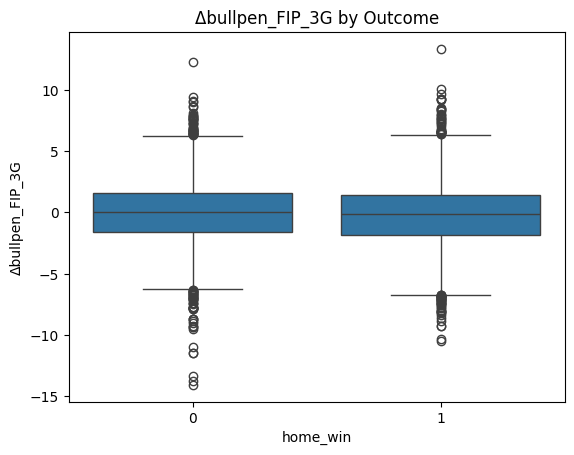

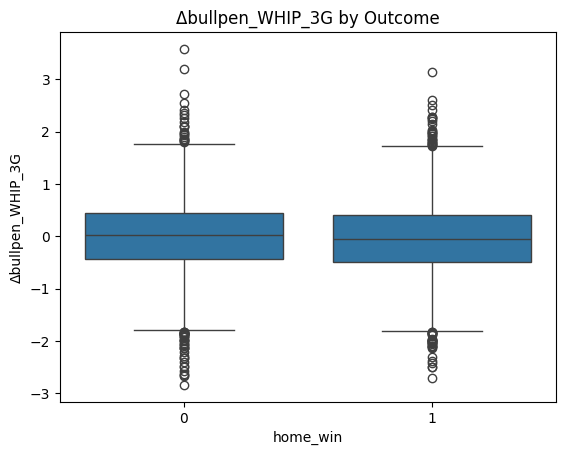

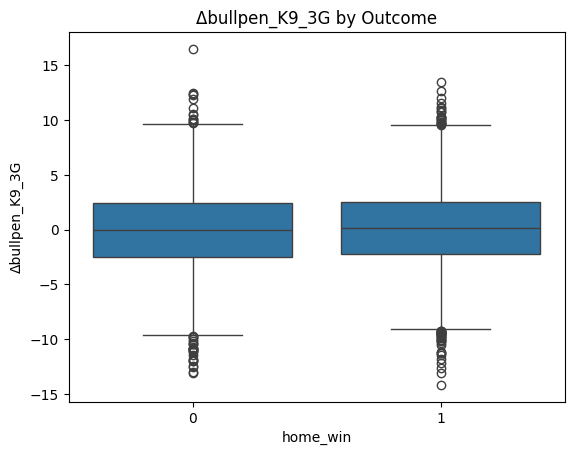

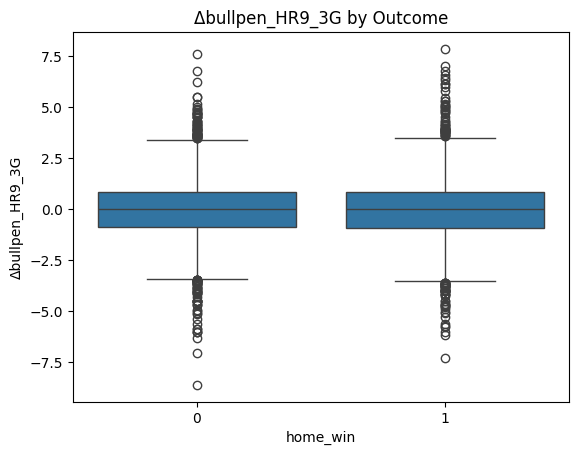

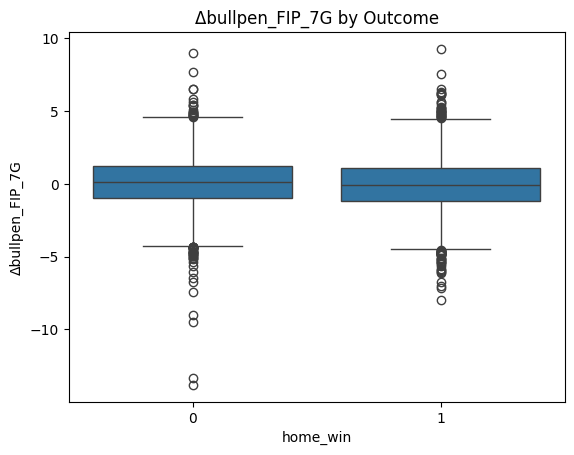

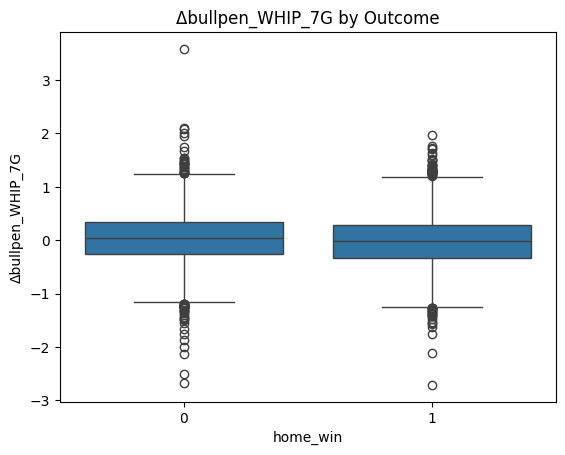

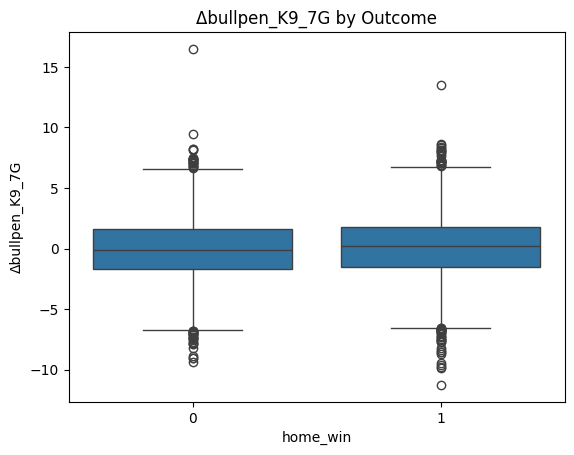

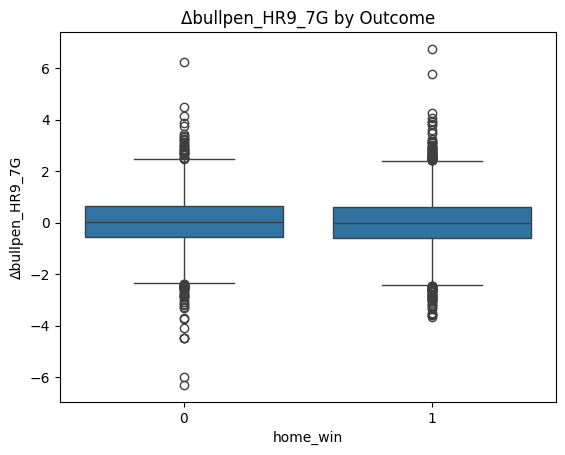

In [14]:
delta_bullpen = game_level_features.filter(like="Δbullpen_")

for col in delta_bullpen.columns:
    plt.figure()
    sns.boxplot(
        data=game_level_features,
        x="home_win",
        y=col
    )
    plt.title(f"{col} by Outcome")
    plt.show()

### Bullpen Delta Features by Game Outcome

Across all bullpen delta features (FIP, WHIP, K9, and HR9) for both the 3-game and 7-game rolling windows, the distributions for home wins and losses overlap substantially. The medians for both outcomes are generally close to zero, indicating that the recent bullpen performance of the two teams is often fairly similar entering a game. As a result, no single bullpen metric clearly separates wins from losses on its own.

However, slight directional tendencies can still be observed. When the home team wins, values of metrics where lower is better (such as $$\Delta FIP$$ and $$\Delta WHIP$$) tend to be slightly more negative, while metrics where higher is better (such as $$\Delta K9$$) tend to be slightly more positive. This suggests that better recent bullpen performance relative to the opponent may contribute modest predictive signal.

Overall, these patterns closely mirror those observed in the starter delta features: pitching advantages appear to matter, but the substantial overlap between the win and loss distributions indicates that bullpen differences alone are unlikely to determine game outcomes without considering other factors such as starting pitching and offensive performance.

### Correlation Analysis

In [28]:
def plot_delta_corr_heatmap(
    df: pd.DataFrame,
    group: str = "pitching",  # "pitching", "batting", "fielding", "all"
    prefix: str = "Δ",
    group_map: dict[str, tuple[str, ...]] | None = None,
    figsize: tuple[int, int] = (12, 10),
    title: str | None = None,
    fmt: str = ".2f",
    annot_fontsize: int = 8,
) -> None:
    """
    Plot a lower-triangle correlation heatmap for delta features.

    Default group_map:
      pitching -> ("Δstarter_", "Δbullpen_")
      batting  -> ("Δroll_",)
      fielding -> ("ΔBIP_",)
      all      -> all columns starting with "Δ"

    Returns None (plots only).
    """

    default_group_map = {
        "pitching": (f"{prefix}starter_", f"{prefix}bullpen_"),
        "batting":  (f"{prefix}roll_",),
        "fielding": (f"{prefix}BIP_",),
        "all":      (prefix,),
    }
    group_map = default_group_map if group_map is None else group_map

    if group not in group_map:
        raise ValueError(f"group must be one of {list(group_map.keys())}. Got: {group}")

    tokens = group_map[group]

    # Select columns
    if group == "all":
        cols = [c for c in df.columns if isinstance(c, str) and c.startswith(prefix)]
    else:
        cols = [c for c in df.columns if isinstance(c, str) and any(c.startswith(t) for t in tokens)]

    if len(cols) < 2:
        raise ValueError(f"Not enough columns found for group='{group}'. Found {len(cols)}.")

    # Sort: 3G before 7G (if present)
    def _win_rank(c: str) -> int:
        cu = c.upper()
        if cu.endswith("_3G"): return 0
        if cu.endswith("_7G"): return 1
        return 2

    cols = sorted(cols, key=lambda c: (_win_rank(c), c))

    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle incl diagonal

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        corr,
        mask=mask,
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        annot=True,          # <-- show text in lower triangle
        fmt=fmt,
        annot_kws={"size": annot_fontsize},
    )

    if title is None:
        title = f"Correlation Heatmap: {group.capitalize()} Delta Features"
    ax.set_title(title)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

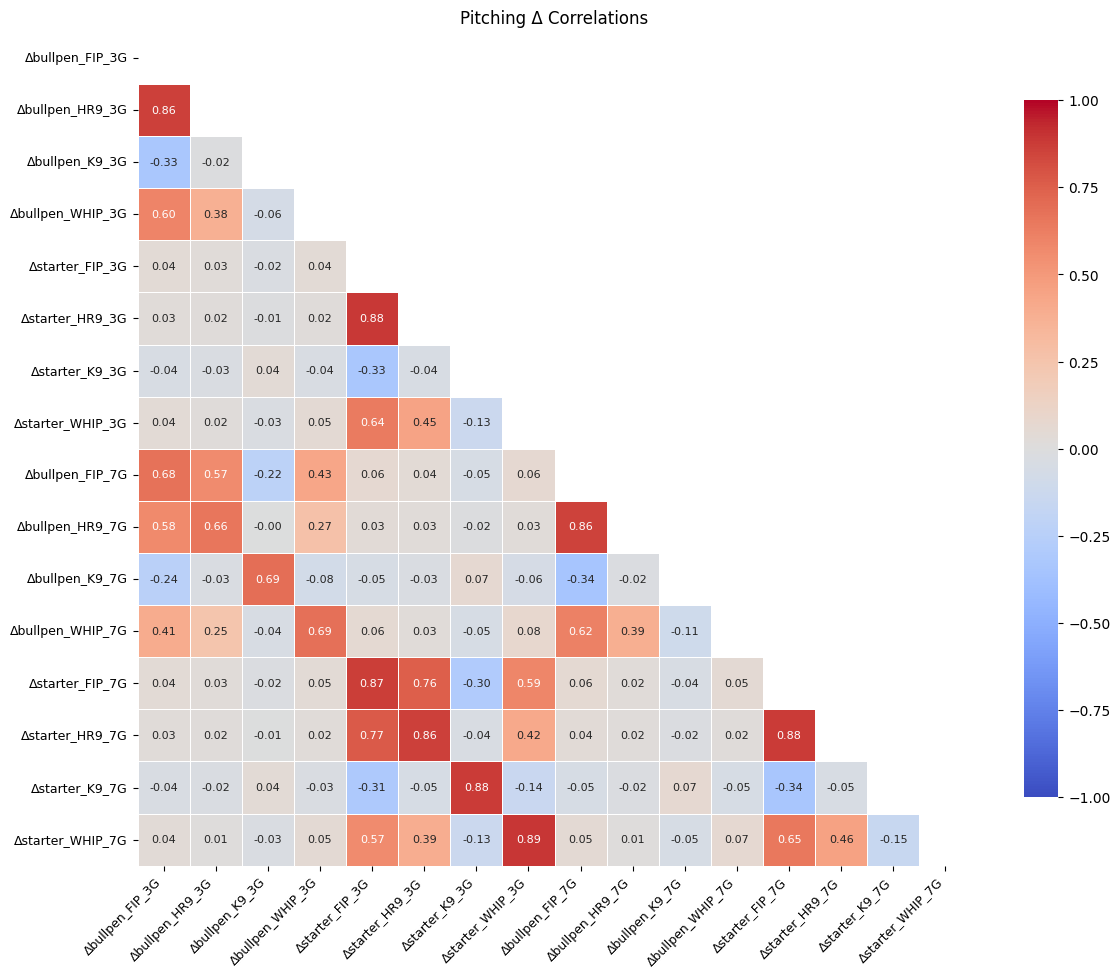

In [29]:
plot_delta_corr_heatmap(game_level_features, group="pitching", title="Pitching Δ Correlations")

#### Pitcher Heatmap Analysis 
| Feature 1          | Feature 2          | Correlation |
|--------------------|--------------------|-------------|
| `Δstarter_WHIP_3G` | `Δstarter_WHIP_7G` | **0.89**    |
| `Δstarter_FIP_3G`  | `Δstarter_HR9_3G`  | **0.88**    |
| `Δstarter_K9_3G`   | `Δstarter_K9_7G`   | **0.88**    |
| `Δstarter_FIP_7G`  | `Δstarter_HR9_7G`  | **0.88**    |
| `Δbullpen_FIP_3G`  | `Δbullpen_HR9_3G`  | **0.86**    |
| `Δbullpen_FIP_7G`  | `Δbullpen_HR9_7G`  | **0.86**    |
| `Δstarter_HR9_3G`  | `Δstarter_HR9_7G`  | **0.86**    |

Two major patterns emerge from the correlation analysis. The first is that **FIP and HR9 are highly correlated**. For example, several pairs such as `Δstarter_FIP_3G` and `Δstarter_HR9_3G` have correlations well above 0.8. This is expected because HR9 is a direct component of FIP, meaning that differences in HR9 between teams strongly influence differences in FIP.

Second, **the 3G and 7G versions of the same metric are strongly correlated**. This pattern appears across both starter and bullpen metrics. This is expected because both rolling windows measure the same underlying skill, with the 7-game window simply providing a smoother estimate of recent performance. To address this during modeling, the **3G and 7G pitching features will be modeled separately**, preventing multicollinearity between different window lengths of the same statistic.

**Additional Notes**

It is also important to note that, while not exceeding the 0.8 threshold, several pairs still exhibit relatively strong correlations. For example, `Δstarter_FIP_7G` and `Δstarter_HR9_3G` have a correlation of 0.76. This further reflects the underlying relationship between HR9 and FIP, as home runs are a direct component of the FIP calculation. As a result, differences in HR9 between teams can still influence FIP even when measured across slightly different rolling windows.